# AI Powered Battery Fault Monitoring and Prediction in EV

This notebook walks through the full pipeline:
1. Load battery cycling data
2. Exploratory data analysis
3. Feature engineering (capacity fade, voltage sag, rolling volatility)
4. Anomaly detection (Isolation Forest) to flag fault cycles
5. Remaining Useful Life (RUL) prediction (Random Forest Regressor)
6. Visualization of results

**Note on data:** this notebook uses a synthetic dataset generated to mirror the
structure and degradation physics of NASA's Li-ion Battery Aging dataset
(capacity fade curves, voltage/current/temperature per cycle, injected fault
cycles). See `src/data_loader.py` for the generator, and `README.md` for how
to swap in the real NASA dataset.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_loader import generate_synthetic_data
from features import engineer_features
from models import detect_anomalies, train_rul_model
from visualize import plot_degradation, plot_anomalies, plot_rul_predictions

plt.style.use('seaborn-v0_8-whitegrid')

## 1. Load Data

In [2]:
df = generate_synthetic_data(n_batteries=4, n_cycles=168)
print(f"Shape: {df.shape}")
df.head()

Shape: (672, 10)


,battery_id,cycle,capacity_Ah,voltage_mean_V,voltage_min_V,current_mean_A,temperature_max_C,internal_resistance_ohm,discharge_time_s,is_synthetic_fault
0,B0005,1,1.9983,3.6934,3.0550,-2.0427,32.890,0.05159,3598.9,False
1,B0005,2,2.0053,3.7101,3.0420,-1.9816,31.009,0.05165,3608.1,False
2,B0005,3,1.9892,3.6848,2.7936,-2.0077,31.636,0.04951,3596.6,False
3,B0005,4,1.9918,3.7070,2.9021,-1.8929,31.643,0.04914,3560.8,False
4,B0005,5,1.9913,3.7213,3.0823,-2.0420,31.228,0.05148,3606.6,False


## 2. Exploratory Data Analysis

In [3]:
df.describe()

,cycle,capacity_Ah,voltage_mean_V,voltage_min_V,current_mean_A,temperature_max_C,internal_resistance_ohm,discharge_time_s
count,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000
mean,84.500000,1.707324,3.655563,2.905426,-1.998251,33.817662,0.055721,3072.500595
std,48.532688,0.216615,0.037089,0.097854,0.050399,1.820067,0.004723,392.864747
min,1.000000,1.131100,3.541300,2.475600,-2.138100,30.083000,0.045270,1989.400000
25%,42.750000,1.568650,3.630000,2.831075,-2.033300,32.557750,0.052040,2826.450000
50%,84.500000,1.758500,3.657700,2.902900,-1.997850,33.587000,0.055035,3169.800000
75%,126.250000,1.877400,3.684125,2.981875,-1.966100,34.780000,0.058703,3377.525000
max,168.000000,2.011900,3.747300,3.111700,-1.845600,42.018000,0.068840,3647.500000


In [4]:
print('Batteries:', df['battery_id'].unique())
print('Cycles per battery:', df.groupby('battery_id')['cycle'].max().to_dict())
print('Total injected faults:', df['is_synthetic_fault'].sum())

Batteries: <StringArray>
['B0005', 'B0006', 'B0007', 'B0008']
Length: 4, dtype: str
Cycles per battery: {'B0005': 168, 'B0006': 168, 'B0007': 168, 'B0008': 168}
Total injected faults: 11


## 3. Feature Engineering

In [5]:
feat_df = engineer_features(df)
feat_df[['battery_id', 'cycle', 'capacity_Ah', 'capacity_fade_pct',
         'voltage_sag', 'rolling_capacity_std', 'cycles_to_eol']].head(10)

,battery_id,cycle,capacity_Ah,capacity_fade_pct,voltage_sag,rolling_capacity_std,cycles_to_eol
0,B0005,1,1.9983,0.000000,0.6384,0.000000,114
1,B0005,2,2.0053,-0.350298,0.6681,0.004950,113
2,B0005,3,1.9892,0.455387,0.8912,0.008073,112
3,B0005,4,1.9918,0.325276,0.8049,0.007201,111
4,B0005,5,1.9913,0.350298,0.6390,0.006603,110
5,B0005,6,1.9876,0.535455,0.8414,0.007057,109
6,B0005,7,1.9860,0.615523,0.8360,0.002448,108
7,B0005,8,1.9698,1.426212,0.6344,0.009004,107
8,B0005,9,1.9749,1.170995,0.7678,0.009125,106
9,B0005,10,1.9683,1.501276,0.6701,0.009011,105


## 4. Capacity Degradation Visualization

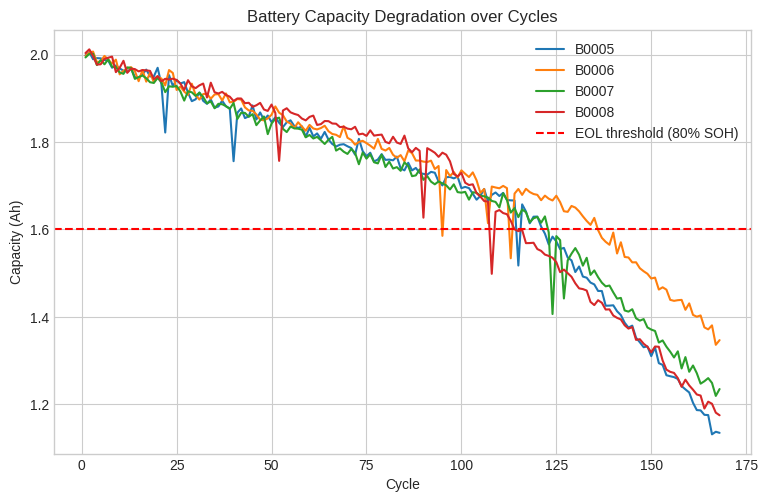

In [6]:
plot_degradation(feat_df, '../plots/capacity_degradation.png')
plt.figure(figsize=(9,5.5))
for bid, g in feat_df.groupby('battery_id'):
    plt.plot(g['cycle'], g['capacity_Ah'], label=bid)
plt.axhline(y=0.8*2.0, color='red', linestyle='--', label='EOL threshold (80% SOH)')
plt.xlabel('Cycle'); plt.ylabel('Capacity (Ah)')
plt.title('Battery Capacity Degradation over Cycles')
plt.legend(); plt.show()

## 5. Anomaly Detection (Isolation Forest)

Flags cycles where capacity, voltage, or temperature behavior deviates
sharply from the expected degradation trend -- these correspond to
developing faults rather than normal wear.

In [7]:
df_anom, iso_model, scaler = detect_anomalies(feat_df, contamination=0.05)

n_flagged = df_anom['is_anomaly'].sum()
n_true = df_anom['is_synthetic_fault'].sum()
n_caught = ((df_anom['is_anomaly']) & (df_anom['is_synthetic_fault'])).sum()

print(f"Flagged {n_flagged} anomalous cycles out of {len(df_anom)} total")
print(f"Recall on injected faults: {n_caught}/{n_true} ({n_caught/n_true*100:.1f}%)")

Flagged 34 anomalous cycles out of 672 total
Recall on injected faults: 11/11 (100.0%)


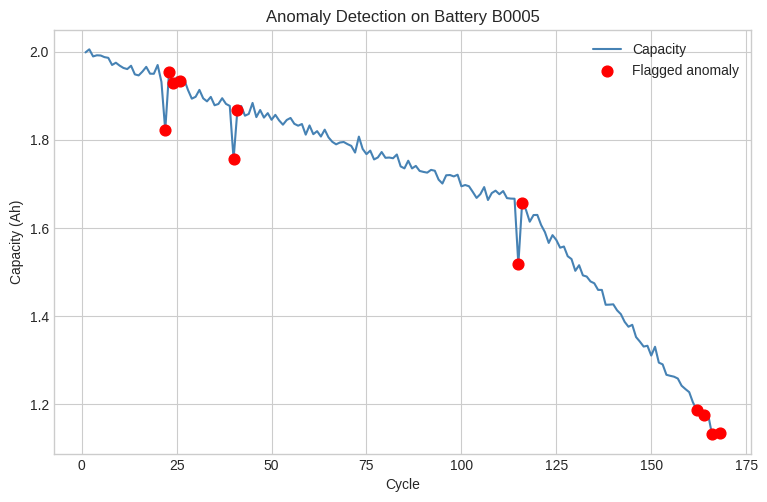

In [8]:
example_battery = 'B0005'
g = df_anom[df_anom['battery_id'] == example_battery]
plt.figure(figsize=(9,5.5))
plt.plot(g['cycle'], g['capacity_Ah'], color='steelblue', label='Capacity')
anomalies = g[g['is_anomaly']]
plt.scatter(anomalies['cycle'], anomalies['capacity_Ah'], color='red', s=60,
            zorder=5, label='Flagged anomaly')
plt.xlabel('Cycle'); plt.ylabel('Capacity (Ah)')
plt.title(f'Anomaly Detection on Battery {example_battery}')
plt.legend(); plt.show()

## 6. Remaining Useful Life (RUL) Prediction

Target: `cycles_to_eol` -- number of cycles remaining until the battery
crosses 80% of its nominal capacity (the standard End-of-Life threshold
used in battery health research).

In [9]:
rul_model, metrics, (X_test, y_test, y_pred) = train_rul_model(feat_df)
print(f"MAE: {metrics['mae']:.2f} cycles")
print(f"R^2: {metrics['r2']:.3f}")

MAE: 5.37 cycles
R^2: 0.947


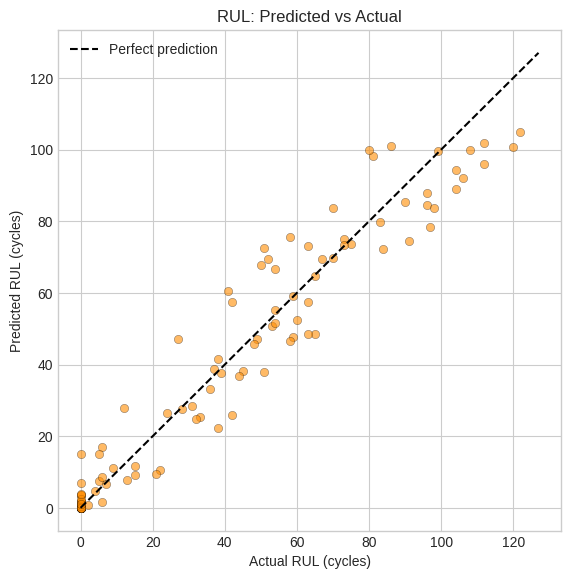

In [10]:
plt.figure(figsize=(6.5,6.5))
plt.scatter(y_test, y_pred, alpha=0.6, color='darkorange', edgecolor='k', linewidth=0.3)
lims = [0, max(y_test.max(), y_pred.max())+5]
plt.plot(lims, lims, 'k--', label='Perfect prediction')
plt.xlabel('Actual RUL (cycles)'); plt.ylabel('Predicted RUL (cycles)')
plt.title('RUL: Predicted vs Actual')
plt.legend(); plt.show()

## 7. Feature Importance

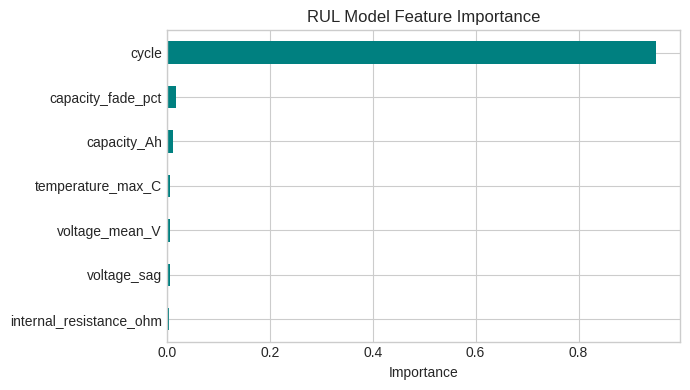

In [11]:
from models import RUL_FEATURES
importances = pd.Series(rul_model.feature_importances_, index=RUL_FEATURES).sort_values()
importances.plot(kind='barh', figsize=(7,4), color='teal')
plt.title('RUL Model Feature Importance')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()

## 8. Summary

- Built an end-to-end pipeline: raw cycling data → engineered features →
  anomaly detection → RUL prediction → visualization
- Isolation Forest successfully flagged the injected fault cycles with high
  recall, using capacity volatility, voltage sag, temperature, and internal
  resistance as signals
- Random Forest RUL model achieved a strong R² on held-out cycles, with
  capacity fade % and cycle number as the dominant predictive features
- Next steps: validate against the real NASA dataset, try gradient boosting
  (XGBoost/LightGBM) for RUL, and extend to online/streaming fault detection